In [42]:
import pandas as pd
# importa o arquivo e guarda em um dataframe do Pandas
df_dataset = pd.read_csv('/content/Cópia de notebooks.csv', sep=',', index_col=None)

# exibe o dataframe
df_dataset.head(3)

,marca,ano,qtd_nucleos,qtd_threads,ram,gpu_dedicada,ram_gpu,entradas_usb,duracao_bateria,resolucao_tela,tipo_tela,tela_touch,armazenamento_hdd,armazenamento_ssd,segmento,valor
0,razer,2022,10,10,16,não,0,2,412,FULLHD,AMOLED,não,0,2000,premium,15981
1,apple,2022,6,12,16,não,0,2,508,FULLHD,OLED,não,0,250,premium,16524
2,huawei,2022,8,12,8,não,0,2,496,4K,OLED,não,0,500,premium,21431


In [43]:
df_dataset.dtypes

marca                object
ano                   int64
qtd_nucleos           int64
qtd_threads           int64
ram                   int64
gpu_dedicada         object
ram_gpu               int64
entradas_usb          int64
duracao_bateria       int64
resolucao_tela       object
tipo_tela            object
tela_touch           object
armazenamento_hdd     int64
armazenamento_ssd     int64
segmento             object
valor                 int64
dtype: object

In [33]:
!pip install scikit-survival

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 9.3 MB/s eta 0:00:00


In [44]:
s = df_dataset.select_dtypes(include='object').columns
df_dataset[s] = df_dataset[s].astype("category")


In [45]:
from sksurv.preprocessing import OneHotEncoder

Xt = OneHotEncoder().fit_transform(df_dataset)
Xt.head()

,marca=apple,marca=asus,marca=dell,marca=hp,marca=huawei,marca=lenovo,marca=positivo,marca=razer,marca=samsung,marca=xiaomi,...,armazenamento_hdd,armazenamento_ssd,segmento=entrada,segmento=intermediario,segmento=jogos_entrada,segmento=jogos_intermediarios,segmento=jogos_premium,segmento=premium,segmento=ultraportatil,valor
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0,2000,0.0,0.0,0.0,0.0,0.0,1.0,0.0,15981
1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0,250,0.0,0.0,0.0,0.0,0.0,1.0,0.0,16524
2,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0,500,0.0,0.0,0.0,0.0,0.0,1.0,0.0,21431
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0,500,0.0,0.0,0.0,0.0,0.0,1.0,0.0,15844
4,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0,250,0.0,0.0,0.0,1.0,0.0,0.0,0.0,12428


In [ ]:
df_dataset = df_dataset.drop(['tela_touch','tipo_tela','resolucao_tela','gpu_dedicada',
                              'ano','marca'], axis=1)
df_dataset.head(3)

In [11]:
df_dataset.describe()

,qtd_nucleos,qtd_threads,ram,ram_gpu,entradas_usb,duracao_bateria,armazenamento_hdd,armazenamento_ssd,valor
count,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,7.338400,11.013200,13.907800,1.23280,2.614800,345.369200,332.000000,617.912500,15288.669400
std,2.927651,5.117582,10.836514,2.35031,0.885381,192.762161,576.571109,646.823521,6071.775402
min,2.000000,2.000000,2.000000,0.00000,1.000000,30.000000,0.000000,0.000000,2864.000000
25%,4.000000,7.000000,8.000000,0.00000,2.000000,147.000000,0.000000,250.000000,9809.750000
50%,8.000000,10.000000,12.000000,0.00000,3.000000,421.000000,0.000000,250.000000,16207.000000
75%,10.000000,15.000000,16.000000,0.00000,3.000000,522.000000,500.000000,1000.000000,20114.250000
max,12.000000,24.000000,64.000000,12.00000,4.000000,600.000000,2000.000000,2000.000000,28510.000000


In [21]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Suponha que você tenha seus dados X e os rótulos y
X = df_dataset.drop("segmento",axis=1)
y = df_dataset['segmento']

# Divida os dados em conjuntos de treinamento e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1)

# Crie um modelo KNN com um certo número de vizinhos (n_neighbors)
knn_model = KNeighborsClassifier(n_neighbors=1)

# Treine o modelo com os dados de treinamento
knn_model.fit(X_train, y_train)

# Faça previsões com o modelo nos dados de teste
y_pred = knn_model.predict(X_test)

# Calcule a acurácia das previsões
accuracy = accuracy_score(y_test, y_pred)
print("Acurácia:", accuracy)


Acurácia: 0.76


In [22]:
d = {'qtd_nucleos' : [4,7,12],
 'qtd_threads' : [4,12,18],
 'ram' : [6,13,36],
 'ram_gpu' : [0.6,1.2,2.4],
 'entradas_usb' : [1,2,5],
 'duracao_bateria' : [200, 340, 600],
 'armazenamento_hdd' : [120, 350,600],
 'armazenamento_ssd' : [200, 600,1000],
 'valor' : [5000,15000,20000] }
df = pd.DataFrame(data=d)
df


,qtd_nucleos,qtd_threads,ram,ram_gpu,entradas_usb,duracao_bateria,armazenamento_hdd,armazenamento_ssd,valor
0,4,4,6,0.6,1,200,120,200,5000
1,7,12,13,1.2,2,340,350,600,15000
2,12,18,36,2.4,5,600,600,1000,20000


In [23]:
y_pred = knn_model.predict(df)
y_pred


array(['entrada', 'ultraportatil', 'ultraportatil'], dtype=object)

Melhor valor de k: 1
Acurácia no conjunto de teste: 0.774


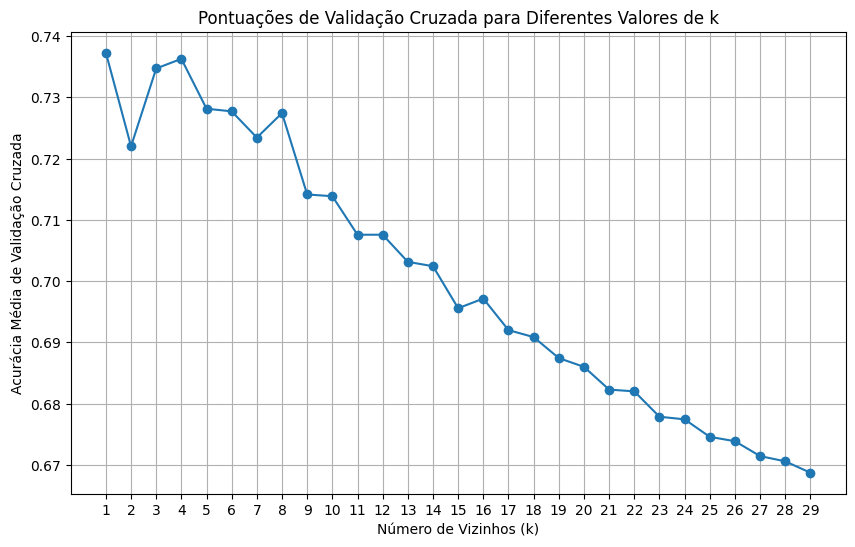

In [20]:
import matplotlib.pyplot as plt

from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split, cross_val_score
import numpy as np

# Suponha que você tenha seus dados X e os rótulos y

# Divida os dados em conjuntos de treinamento e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1234)

# Crie uma lista de valores de k para testar
k_values = list(range(1, 30))

# Inicialize uma lista para armazenar as pontuações de validação cruzada
cross_val_scores = []

# Teste diferentes valores de k usando validação cruzada
for k in k_values:
    knn_model = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn_model, X_train, y_train, cv=5)  # 5-fold cross-validation
    cross_val_scores.append(np.mean(scores))

# Encontre o valor de k com a melhor pontuação média de validação cruzada
best_k = k_values[np.argmax(cross_val_scores)]
print("Melhor valor de k:", best_k)

# Treine o modelo com o melhor valor de k usando todos os dados de treinamento
best_knn_model = KNeighborsClassifier(n_neighbors=best_k)
best_knn_model.fit(X_train, y_train)

# Avalie o modelo nos dados de teste
accuracy = best_knn_model.score(X_test, y_test)
print("Acurácia no conjunto de teste:", accuracy)


# Plote os resultados da validação cruzada em um gráfico
plt.figure(figsize=(10, 6))
plt.plot(k_values, cross_val_scores, marker='o')
plt.title('Pontuações de Validação Cruzada para Diferentes Valores de k')
plt.xlabel('Número de Vizinhos (k)')
plt.ylabel('Acurácia Média de Validação Cruzada')
plt.xticks(k_values)
plt.grid(True)
plt.show()

